# 5. Which tool should own each of Marketing's and Finance's recurring numbers, and which would you refuse for Finance?

**Week 2, Thursday. Chapter 5 of 6.** Chapter 4 found that plain Python, SQL and pandas agree, 130 reached and 107 bought, once they share one definition of a customer's segment. This chapter decides where each of the day's recurring numbers should live, starting with Finance's.

> **The client asks.** "Now tell me honestly which tool you would pick for which job. I will ask
> you which one you would refuse to use for Finance's numbers, so have a reason ready."
>
> Kavya Nair, senior analyst, Kalpa Retail data team

**Who needs the answer.** Kavya, and behind Kavya, Anand Iyer, the finance controller, whose
analyst reruns every number the team sends, line by line. The note decides where each recurring
number lives. A number that lives in two tools drifts into two numbers, and two numbers for one
metric is how Week 1 Wednesday began, with the dashboard's Rs 2.1 crore against the books' Rs
1.9 crore and a month lost to the argument.

**The questions on the way.**

1. Which of three tools should compute Finance's Monday revenue, and what does each cost?
2. Does speed separate the three tools on 1,000 orders?
3. How many rows does each tool move to answer an eight-row question?
4. Which tool should own each of the day's recurring asks, and which would you refuse for Finance?
5. Does the growth team's table reconcile with Finance's query to the rupee?

**The metric at stake.** The day's recurring numbers and the tool that owns each. The one the chapter tests is Finance's
Monday revenue by segment and quarter: eight numbers, four segments by two quarters, adding up
to Rs 19,84,00,000, which Anand's analyst reruns every week.

**Who else faces it.** LinkedIn met the cost of one metric living in many places. The page for its Unified Metrics
Platform says that "multiple stakeholders come up with different ways to calculate the same
metric arriving at slightly different results", and that the platform now "serves as the single
source of truth for all business metrics at Linkedin" (LinkedIn Engineering, Unified Metrics
Platform, checked 30 Sep 2026).

`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, the retail dossier, has the business behind these numbers: section 3 for GMV, section 5 for frequency and repeat rate, and section 2 for Retail-Plus, the paid tier.

**Setup.** The next cell reads the orders and the customer list from the warehouse and rebuilds
chapter 1's table, so the growth team's frame is in memory as it would be on a working Monday.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()                  # the Kalpa warehouse in Postgres, read only
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

# Chapter 1's table: one row per customer on the list, with the three numbers.
rfm = (orders.groupby("customer_id")
             .agg(last_order=("order_date", "max"), frequency=("order_id", "count"),
                  spend=("amount", "sum"))
             .reset_index())
table = customers.merge(rfm, on="customer_id", how="left", validate="one_to_one")
table = table.assign(frequency=table["frequency"].fillna(0).astype("int64"),
                     spend=table["spend"].fillna(0))
print(f"chapter 1's table: {len(table)} customers, {int((table['frequency'] == 0).sum())} never ordered")

1,000 orders and 340 customers read from the warehouse
chapter 1's table: 340 customers, 39 never ordered


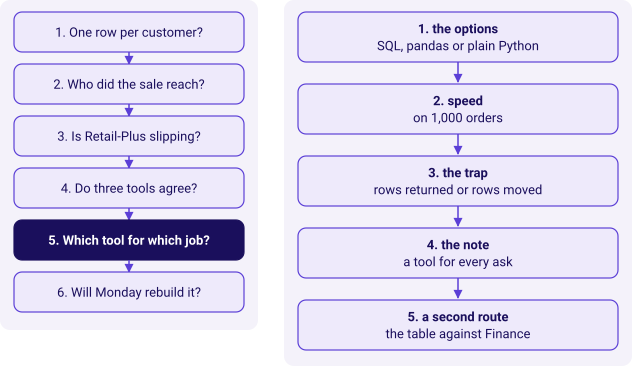

In [2]:
kit.side_by_side(
    kit.ladder(["One row per customer?", "Who did the sale reach?", "Is Retail-Plus slipping?", "Do three tools agree?", "Which tool for which job?", "Will Monday rebuild it?"], lit=4, show=False),
    kit.vflow(["1. the options\nSQL, pandas or plain Python", "2. speed\non 1,000 orders", "3. the trap\nrows returned or rows moved", "4. the note\na tool for every ask", "5. a second route\nthe table against Finance"], show=False),
)

## 1. Which of three tools should compute Finance's Monday revenue, and what does each cost?

| Option | How it works | Where the logic lives |
|---|---|---|
| a) SQL | The warehouse joins orders to customers, groups by segment and quarter, and sends back the answer | In a query file anyone with read access can run |
| b) pandas | The growth team's notebook reads the orders and the customer list, merges and groups them | In a notebook on the analyst's machine |
| c) Plain Python | A script fetches the rows and adds them up in a dictionary keyed by segment and quarter | In a script on the analyst's machine |

The next cell writes each out and sizes it on what Finance cares about: the lines a reviewer
must read, where the number can be rerun, and what the number depends on besides the data.

option,lines of logic,where Anand's analyst can rerun it,what it depends on besides the data
a) SQL,5,anywhere with read access,the warehouse only
b) pandas,4,on the analyst's machine,the notebook's state and environment
c) plain Python,6,on the analyst's machine,the script's environment


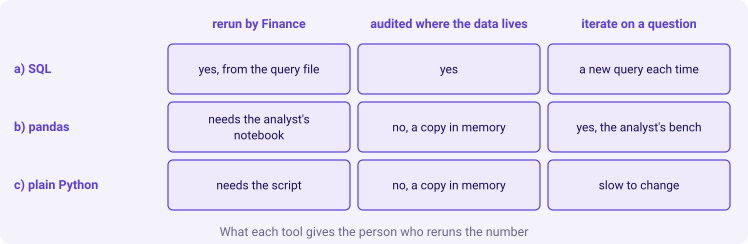

In [3]:
import inspect

FIN_SQL = """SELECT c.segment, o.quarter, sum(o.amount) AS revenue
FROM   orders o
JOIN   customers c ON c.customer_id = o.customer_id
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;"""

def finance_sql():
    answer = pd.read_sql(FIN_SQL, ENG)
    return answer, len(answer)                  # the answer, and the rows that left the warehouse

def finance_pandas():
    o = pd.read_sql("SELECT customer_id, quarter, amount FROM orders", ENG)
    c = pd.read_sql("SELECT customer_id, segment FROM customers", ENG)
    answer = (o.merge(c, on="customer_id", how="left", validate="many_to_one")
               .groupby(["segment", "quarter"], as_index=False)["amount"].sum())
    return answer, len(o) + len(c)

def finance_python():
    rows = kit.sql("SELECT o.quarter, o.amount, c.segment FROM orders o "
                   "JOIN customers c ON c.customer_id = o.customer_id")
    answer = {}
    for r in rows:
        key = (r["segment"], r["quarter"])
        answer[key] = answer.get(key, 0) + r["amount"]
    return answer, len(rows)

routes = {"a) SQL": finance_sql, "b) pandas": finance_pandas, "c) plain Python": finance_python}
lines = {"a) SQL": len(FIN_SQL.splitlines()),
         "b) pandas": len(inspect.getsource(finance_pandas).splitlines()) - 2,
         "c) plain Python": len(inspect.getsource(finance_python).splitlines()) - 2}
sizing = [("a) SQL", lines["a) SQL"], "anywhere with read access", "the warehouse only"),
          ("b) pandas", lines["b) pandas"], "on the analyst's machine", "the notebook's state and environment"),
          ("c) plain Python", lines["c) plain Python"], "on the analyst's machine", "the script's environment")]
kit.table(["option", "lines of logic", "where Anand's analyst can rerun it", "what it depends on besides the data"],
          sizing, caption="Three ways to compute Finance's Monday revenue")
kit.matrix(["a) SQL", "b) pandas", "c) plain Python"], ["rerun by Finance", "audited where the data lives", "iterate on a question"],
           [["yes, from the query file", "yes", "a new query each time"],
            ["needs the analyst's notebook", "no, a copy in memory", "yes, the analyst's bench"],
            ["needs the script", "no, a copy in memory", "slow to change"]],
           title="What each tool gives the person who reruns the number")

**The best-fit call: a, SQL.** Anand's analyst has to rerun the number every Monday without the
growth team's machine, and only the query runs where the data lives, on nothing but the data.
**The fact that would change it:** a Finance question that needs iteration, such as a new cut
tried five ways in an afternoon. Then pandas reads the query's answer and works on that, and the
definition still lives in one place. Speed and rows are the two sizes still missing; the next
two questions measure them.

## 2. Does speed separate the three tools on 1,000 orders?

A hurried note ranks tools by speed. The cell below runs all three routes end to end, from the
warehouse to the eight numbers, and times each.

**Predict before you run.** Which is true on Kalpa's 1,000 orders? a) SQL is ten times faster
than the rest; b) pandas is ten times faster than the rest; c) all three finish well inside a
second; d) plain Python takes over a minute.

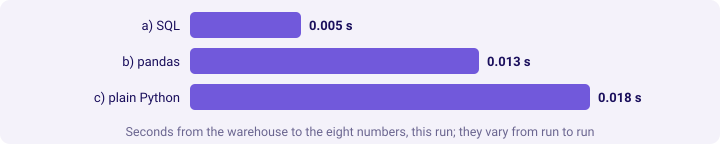

In [4]:
import time
timings = {}
for name, route in routes.items():
    start = time.perf_counter()
    route()
    timings[name] = time.perf_counter() - start
kit.bars([(k, round(v, 3)) for k, v in timings.items()], fmt=lambda v: f"{v:.3f} s",
         title="Seconds from the warehouse to the eight numbers, this run; they vary from run to run")
kit.check("every route finishes well inside a second on 1,000 orders", all(v < 1 for v in timings.values()),
          ", ".join(f"{k} {v:.3f} s" for k, v in timings.items()))

**What happened.** The answer is c. On a thousand orders every route finishes in a fraction of a
second, and the ranking changes from one run to the next, so speed separates nothing here. A
sizing column where every option scores the same is no reason to choose.

## 3. How many rows does each tool move to answer an eight-row question?

**The plausible wrong answer.** The hurried note sizes each tool by its answer: each returns the
same eight rows, four segments by two quarters, so the note calls the cost equal and picks
pandas for Finance, because its chain is short and the growth team already uses it.

**Predict before you run.** How many rows did the pandas route actually move out of the
warehouse to produce its eight? a) 8; b) 340; c) 1,000; d) 1,340.

option,rows in the answer
a) SQL,8
b) pandas,8
c) plain Python,8


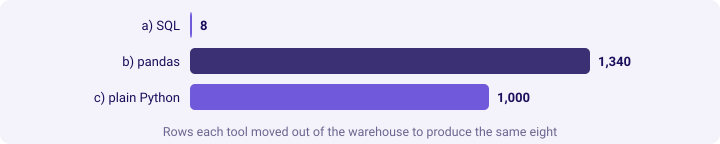

In [5]:
(fin_sql, moved_sql), (fin_pd, moved_pd), (fin_py, moved_py) = (finance_sql(), finance_pandas(),
                                                          finance_python())
returned = [("a) SQL", len(fin_sql)), ("b) pandas", len(fin_pd)), ("c) plain Python", len(fin_py))]
kit.table(["option", "rows in the answer"], returned, caption="The hurried note's sizing: the answer's rows")
moved = [("a) SQL", moved_sql), ("b) pandas", moved_pd), ("c) plain Python", moved_py)]
kit.bars(moved, lit=(1,), title="Rows each tool moved out of the warehouse to produce the same eight")

**What happened.** The answer is d, 1,340: the pandas route pulled every order and every
customer, 1,000 and 340, to add them up on the analyst's machine. Plain Python pulled 1,000.
SQL moved 8, the answer itself.

**Why it is wrong.** The rows an answer holds say nothing about the work of producing it. Sized
by rows returned, the three tools tie at 8; sized by rows moved, SQL moves 8 and pandas 1,340,
and the gap grows with the orders table: at a hundred times Kalpa's orders the pandas route
moves a hundred times the rows while SQL still sends 8. A note that picked pandas for Finance on
the tie would also have put Finance's number where Anand's analyst cannot rerun it. The check
that catches it: count the rows each route fetched, which the cell below does, before comparing
anything else.

In [6]:
kit.check("all three answers hold eight rows", len(fin_sql) == len(fin_pd) == len(fin_py) == 8)
kit.check("the pandas route moved 1,340 rows for those eight", moved_pd == 1340)
kit.check("plain Python moved 1,000 and SQL only its answer", moved_py == 1000 and moved_sql == 8)
kit.check("the three routes agree on every one of the eight numbers",
          all(fin_py[(r.segment, r.quarter)] == r.revenue == fin_pd.set_index(["segment", "quarter"]).loc[(r.segment, r.quarter), "amount"]
              for r in fin_sql.itertuples()))

**The fix, and what changed.** Size a route by the rows it moves and by who must rerun it. Moved
rows put SQL at 8 against pandas at 1,340, about 168 times as many on today's data, and the rerun
question had already put Finance's number in SQL. The note's line for Finance does not change;
its reason is now a number instead of a preference.

## 4. Which tool should own each of the day's recurring asks, and which would you refuse for Finance?

The note Kavya asked for, one line per ask, each with its owner and its reason. The four asks
are the day's: Finance's Monday revenue, the growth team's customer table, the head of
Retail-Plus's months view, and an auditor who wants one customer's spend explained step by step.

**Predict before you run.** Which ask should plain Python own? a) Finance's Monday revenue;
b) the growth team's customer table; c) the head of Retail-Plus's months view; d) the auditor's
one customer, step by step.

the ask,the owner,the reason
Finance's revenue by segment and quarter,SQL,Anand's analyst reruns it where the data lives; it moves 8 rows
The growth team's customer table,"pandas, reading the warehouse",the analysts add columns every week; merge and validate are one line each
The head of Retail-Plus's months view,pandas,a pivot and a melt on data already in memory
"One customer's spend, for an auditor",plain Python,every step is a line the auditor can read


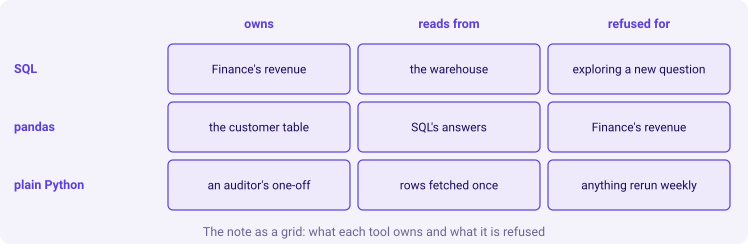

In [7]:
note = [("Finance's revenue by segment and quarter", "SQL", "Anand's analyst reruns it where the data lives; it moves 8 rows"),
        ("The growth team's customer table", "pandas, reading the warehouse", "the analysts add columns every week; merge and validate are one line each"),
        ("The head of Retail-Plus's months view", "pandas", "a pivot and a melt on data already in memory"),
        ("One customer's spend, for an auditor", "plain Python", "every step is a line the auditor can read")]
kit.table(["the ask", "the owner", "the reason"], note, caption="The tool-choice note")
kit.matrix(["SQL", "pandas", "plain Python"], ["owns", "reads from", "refused for"],
           [["Finance's revenue", "the warehouse", "exploring a new question"],
            ["the customer table", "SQL's answers", "Finance's revenue"],
            ["an auditor's one-off", "rows fetched once", "anything rerun weekly"]],
           title="The note as a grid: what each tool owns and what it is refused")
kit.check("every ask has one owner", len(note) == 4 and all(owner for _, owner, _ in note))
kit.check("Finance's number is owned by SQL", note[0][1] == "SQL")

**What happened.** The answer is d. The auditor's question is asked once and has to be read line
by line, which is what a plain loop offers. The refusal the note carries: **never a pandas
notebook for Finance's number.** It moves every order to one machine, it runs on a copy, and
Anand's analyst cannot rerun it without the growth team's notebook and its state. pandas stays
the growth team's bench, reading what SQL computes.

> **Kavya's review.** "Choose by who has to trust the number and rerun it, and size by the rows
> a route moves. Finance's number lives in the warehouse, the growth team's table reads from it,
> and plain Python is for the question you must explain line by line."

## 5. Does the growth team's table reconcile with Finance's query to the rupee?

A number that lives in one place still has to agree with every copy made from it. The growth
team's table carries spend per customer over both quarters; adding it up by segment must give
Finance's query, summed over the two quarters, to the rupee. The two share no code: one is
chapter 1's `groupby` and merge, the other is SQL.

segment,the growth team's table,"Finance's query, both quarters"
Business,"Rs 19,65,99,040","Rs 19,65,99,040"
Retail-Core,"Rs 7,39,320","Rs 7,39,320"
Retail-Plus,"Rs 9,99,150","Rs 9,99,150"
Student,"Rs 62,490","Rs 62,490"


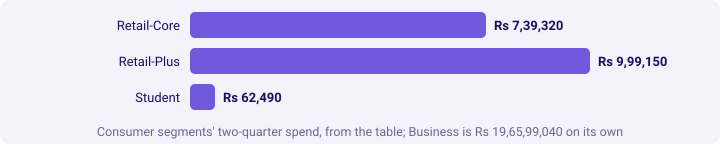

In [8]:
from_table = table.groupby("segment")["spend"].sum()
from_finance = fin_sql.groupby("segment")["revenue"].sum().astype(float)
segs = from_table.index.tolist()
kit.table(["segment", "the growth team's table", "Finance's query, both quarters"],
          [(s, kit.rupees(from_table[s]), kit.rupees(from_finance[s])) for s in segs],
          caption="The table against Finance, segment by segment")
kit.bars([(s, from_table[s]) for s in segs if s != "Business"], fmt=kit.rupees,
         title="Consumer segments' two-quarter spend, from the table; Business is Rs 19,65,99,040 on its own")
kit.check("every segment agrees to the rupee", all(from_table[s] == from_finance[s] for s in segs))
kit.check("both add up to Rs 19,84,00,000", from_table.sum() == from_finance.sum() == 198_400_000)

**When to switch.** This reconciliation is the check that lets two tools share one number: run it
every Monday, and when it fails, the warehouse is right and the table is wrong until someone
can say why. Chapter 6 puts it inside the refresh.

### How would you answer this chapter's questions in an interview?

**[D] Same question, three tools: how do you choose, and defend one choice?** "When they agree,
I choose by who has to trust and rerun the number. Finance's number goes in SQL, because it runs
where the data lives, moves only its answer and Finance can rerun it from the query. The
analyst's iterative work goes in pandas, reading SQL's answers. A one-off I must explain line by
line goes in plain Python. On 1,000 rows speed separates nothing, so I size by rows moved: SQL 8,
pandas 1,340."

**[D] Which tool would you refuse for Finance's numbers, and why?** "A pandas notebook run by
hand. It moves every order to one machine, depends on the order its cells were run in, and
Finance cannot rerun it without my environment. I would give Finance the query and let my
notebook read the query's answer."

**[F] When would you move a pandas step into SQL?** "When the step aggregates a large table
into a small answer, when someone else must rerun it, or when two teams need the same
definition. The warehouse sends the answer, and pandas works on the answer."

### Going deeper: how can pandas read Finance's definition instead of copying it?

A view is a named query stored in the database. Once Finance's query is a view, the growth
team's notebook reads the view and never retypes the logic, so the two cannot drift. The cell
below makes a temporary view, which lasts only as long as its connection, so it changes nothing
in the shared warehouse; a permanent view is the data platform lead's to create.

In [9]:
from sqlalchemy import text
with ENG.connect() as con:
    con.execute(text("CREATE TEMP VIEW finance_revenue AS " + FIN_SQL.rstrip(";")))
    from_view = pd.read_sql("SELECT * FROM finance_revenue", con)
kit.check("pandas reading the view gets Finance's eight numbers exactly",
          from_view.equals(fin_sql), f"{len(from_view)} rows")

**The answers, question by question.**

1. SQL computes Finance's Monday revenue, because Anand's analyst reruns it where the data lives;
   pandas and plain Python would put it on the analyst's machine.
2. Speed separates nothing on 1,000 orders: all three routes finish well inside a second.
3. Each route returns 8 rows, but SQL moves 8 and pandas 1,340, which is the size that separates
   them.
4. SQL owns Finance's revenue, pandas the customer table and the months view, plain Python the
   auditor's one-off; a pandas notebook is refused for Finance.
5. The growth team's table reconciles with Finance's query in every segment, Rs 19,84,00,000 in
   all.

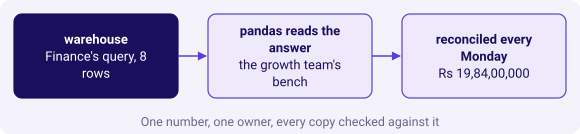

Next: chapter 6 makes the growth team's table rebuild itself every Monday and stop when a check fails.


In [10]:
kit.flow(["warehouse\nFinance's query, 8 rows", "pandas reads the answer\nthe growth team's bench",
          "reconciled every Monday\nRs 19,84,00,000"], lit=0,
         title="One number, one owner, every copy checked against it")
kit.check_summary()
print("Next: chapter 6 makes the growth team's table rebuild itself every Monday and stop when a check fails.")